In [1]:
# Define the default font sizes to make the figures prettier:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from scipy import signal
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

#### 6.7 COMPUTER EXPERIMENT ON ADAPTIVE PREDICTION

For our first experiment with the $\mathbf{LMS}$ $\mathbf{algorithm}$, we study a first-order, $\mathbf{autoregressive}$ ($\mathbf{AR}$) process using $\mathbf{real-valued}$ $\mathbf{data}$. The process is described by the following $\mathbf{difference}$ $\mathbf{equation}$:
$$u(n) = -au(n-1) + v(n), \quad \text{(6.106)}$$
where $a$ is the (one and only) parameter of the process and $v(n)$ is a $\mathbf{zero-mean}$ $\mathbf{white-noise}$ process of variance $\sigma_v^2$. To estimate the parameter $a$, we use an $\mathbf{adaptive}$ $\mathbf{predictor}$ of $\mathbf{order}$ $\mathbf{one}$, as depicted in Fig. 6.14. The $\mathbf{real}$ $\mathbf{LMS}$ $\mathbf{algorithm}$ for adaptation of the (one and only) tap weight of the predictor is written as
$$\hat{w}(n+1) = \hat{w}(n) + \mu u(n-1)f(n), \quad \text{(6.107)}$$
where
$$f(n) = u(n) - \hat{w}(n)u(n-1)$$
is the $\mathbf{prediction}$ $\mathbf{error}$.

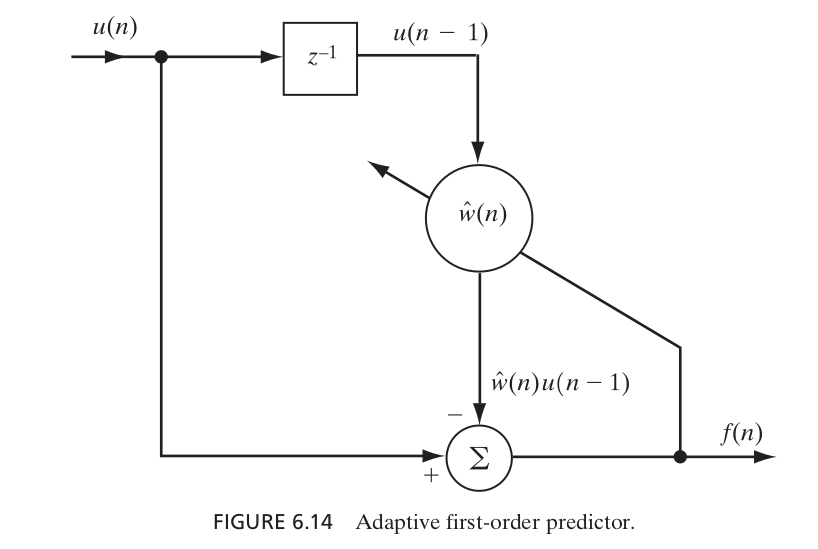

The experiment is performed for the following parameterization of the AR process, assumed to have zero mean: \
    AR parameter, $a = -0.99$ \
    Variance of the process, $\sigma_u^2=0.936$

#### Objective I. Learning Curves for Varying $\mu$

Figure 6.15 shows experimental plots of the $\mathbf{learning}$ $\mathbf{curves}$ of the $\mathbf{LMS}$ $\mathbf{algorithm}$ [i.e., the $\mathbf{mean-square}$ $\mathbf{error}$ $J(n)$ versus the $\mathbf{number}$ $\mathbf{of}$ $\mathbf{adaptation}$ $\mathbf{cycles}$, $n$] for the $\mathbf{AR}$ $\mathbf{parameter}$ $a$ previously and $\mathbf{varying}$ $\mathbf{step-size}$ $\mathbf{parameter}$ $\mu$. Specifically, the values used for $\mu$ are $0.01$, $0.05$, and $0.1$. The $\mathbf{ensemble}$ $\mathbf{averaging}$ was performed over $\mathbf{100}$ $\mathbf{independent}$ $\mathbf{Monte}$ $\mathbf{Carlo}$ $\mathbf{runs}$ of the experiment. The plots of Fig. 6.15 confirm the following properties:
* As the step-size parameter $\mu$ is reduced, the rate of convergence of the LMS algo-
rithm is correspondingly increased
* A reduction in the  step-size  parameter $\mu$ also has the effect of  reducing  variation in the experimentally computed learning curve.

Correlation Matrix R:
[[0.986]]
Maximum eigenvalue λ_max: 0.986000
Convergence condition: μ < 2.028398
μ = 0.0050: Satisfies convergence condition = True
μ = 0.0100: Satisfies convergence condition = True
μ = 0.0200: Satisfies convergence condition = True
μ = 0.0010: Satisfies convergence condition = True


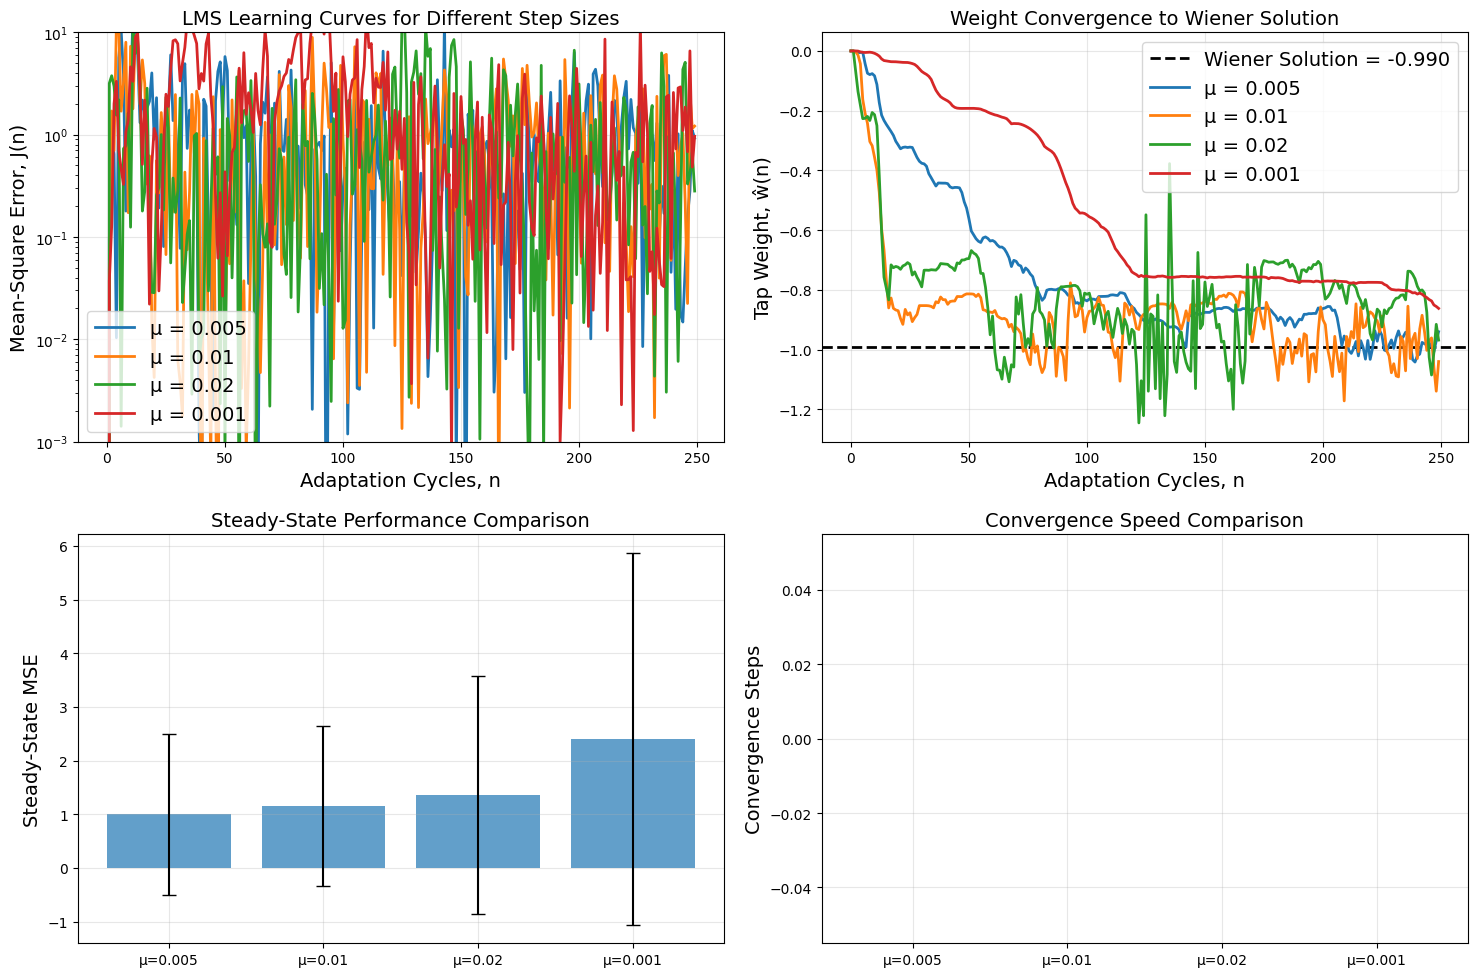


=== Statistical Information ===
Wiener solution: w_o = -0.990000
Minimum mean-square error J_min = σ_v² = 0.019621

Convergence Performance:
μ = 0.0050:
  Final weight: -0.940140, Error: 0.049860
  Steady-state MSE: 1.002655
  Convergence steps: 0
μ = 0.0100:
  Final weight: -1.039960, Error: 0.049960
  Steady-state MSE: 1.158954
  Convergence steps: 0
μ = 0.0200:
  Final weight: -0.968078, Error: 0.021922
  Steady-state MSE: 1.359800
  Convergence steps: 0
μ = 0.0010:
  Final weight: -0.862020, Error: 0.127980
  Steady-state MSE: 2.408185
  Convergence steps: 0

=== Theoretical Analysis ===
Theoretical minimum MSE J_min: 0.019621
Eigenvalue λ: 0.986000
μ = 0.0050:
  Theoretical excess MSE: 0.000048
  Theoretical total MSE: 0.019670
  Theoretical misadjustment: 0.002471
μ = 0.0100:
  Theoretical excess MSE: 0.000097
  Theoretical total MSE: 0.019719
  Theoretical misadjustment: 0.004954
μ = 0.0200:
  Theoretical excess MSE: 0.000195
  Theoretical total MSE: 0.019817
  Theoretical misa

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters setup
N_samples = 250
N_ensemble = 1
mus = [0.005, 0.01, 0.02, 0.001]   # μ < 0.04

a = 0.99
u_var = 0.986
u_std = np.sqrt(u_var)
np.random.seed(6)

def calculate_correlation_matrix(a, u_var, order=1):
    """Calculate correlation matrix for 1st order AR process"""
    # For 1st order AR process: r(k) = (-a)^|k| * u_var / (1 - a^2)
    r0 = u_var
    r1 = -a * u_var / (1 - a**2)
    
    R = np.array([[r0]])
    
    return R

# Calculate correlation matrix
R = calculate_correlation_matrix(a, u_var)
print("Correlation Matrix R:")
print(R)
print(f"Maximum eigenvalue λ_max: {R[0,0]:.6f}")
print(f"Convergence condition: μ < {2/R[0,0]:.6f}")

# Verify step-size parameters
for mu in mus:
    condition = mu < 2/R[0,0]
    print(f"μ = {mu:.4f}: Satisfies convergence condition = {condition}")

# Run LMS algorithm
err_hist = {mu: np.zeros(N_samples) for mu in mus}
w_hist = {mu: np.zeros(N_samples) for mu in mus}  # Track weights

for mu in mus:
    mse_runs = np.zeros((N_ensemble, N_samples))
    weight_runs = np.zeros((N_ensemble, N_samples))

    for m in range(N_ensemble):
        u = np.zeros(N_samples + 1)
        w = 0.0

        for n in range(1, N_samples):
            # Generate AR process
            u[n] = -a * u[n-1] + np.random.randn() * u_std
            # Calculate prediction error
            e = u[n] - w * u[n-1]
            # LMS update
            w = w + mu * u[n-1] * e
            # Record results
            mse_runs[m, n] = e * e
            weight_runs[m, n] = w

    err_hist[mu] = np.mean(mse_runs, axis=0)
    w_hist[mu] = np.mean(weight_runs, axis=0)

# Plot results
plt.figure(figsize=(15, 10))

# 1. Learning curves
plt.subplot(2, 2, 1)
for mu in mus:
    plt.semilogy(range(N_samples), err_hist[mu], label=f'μ = {mu}', linewidth=2)

plt.xlabel('Adaptation Cycles, n')
plt.ylabel('Mean-Square Error, J(n)')
plt.title('LMS Learning Curves for Different Step Sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1e-3, 1e1)

# 2. Weight convergence
plt.subplot(2, 2, 2)
wienerSol = -a  # For 1st order AR process, Wiener solution is -a
plt.axhline(y=wienerSol, color='black', linestyle='--', 
           label=f'Wiener Solution = {wienerSol:.3f}', linewidth=2)

for mu in mus:
    plt.plot(range(N_samples), w_hist[mu], label=f'μ = {mu}', linewidth=2)

plt.xlabel('Adaptation Cycles, n')
plt.ylabel('Tap Weight, ŵ(n)')
plt.title('Weight Convergence to Wiener Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Steady-state error comparison
plt.subplot(2, 2, 3)
steady_state_start = 50  # Assume steady-state after 50 iterations
steady_state_errors = []
steady_state_std = []

for mu in mus:
    steady_state_data = err_hist[mu][steady_state_start:]
    steady_state_errors.append(np.mean(steady_state_data))
    steady_state_std.append(np.std(steady_state_data))

plt.bar(range(len(mus)), steady_state_errors, 
        yerr=steady_state_std, capsize=5, alpha=0.7)
plt.xticks(range(len(mus)), [f'μ={mu}' for mu in mus])
plt.ylabel('Steady-State MSE')
plt.title('Steady-State Performance Comparison')
plt.grid(True, alpha=0.3)

# 4. Convergence speed comparison
plt.subplot(2, 2, 4)
convergence_threshold = 0.1  # Define convergence threshold
convergence_steps = []

for mu in mus:
    mse_data = err_hist[mu]
    # Find first position below threshold
    below_threshold = np.where(mse_data < convergence_threshold)[0]
    if len(below_threshold) > 0:
        convergence_steps.append(below_threshold[0])
    else:
        convergence_steps.append(N_samples)

plt.bar(range(len(mus)), convergence_steps, alpha=0.7)
plt.xticks(range(len(mus)), [f'μ={mu}' for mu in mus])
plt.ylabel('Convergence Steps')
plt.title('Convergence Speed Comparison')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical information
print("\n=== Statistical Information ===")
print(f"Wiener solution: w_o = {wienerSol:.6f}")
print(f"Minimum mean-square error J_min = σ_v² = {u_var * (1 - a**2):.6f}")

print("\nConvergence Performance:")
for i, mu in enumerate(mus):
    final_weight = w_hist[mu][-1]
    weight_error = abs(final_weight - wienerSol)
    steady_state_mse = np.mean(err_hist[mu][steady_state_start:])
    
    print(f"μ = {mu:.4f}:")
    print(f"  Final weight: {final_weight:.6f}, Error: {weight_error:.6f}")
    print(f"  Steady-state MSE: {steady_state_mse:.6f}")
    print(f"  Convergence steps: {convergence_steps[i]}")

# Calculate theoretical performance
print("\n=== Theoretical Analysis ===")
J_min = u_var * (1 - a**2)  # Minimum mean-square error
lambda_val = R[0,0]  # Eigenvalue

print(f"Theoretical minimum MSE J_min: {J_min:.6f}")
print(f"Eigenvalue λ: {lambda_val:.6f}")

for mu in mus:
    # Theoretical excess MSE
    excess_mse_theoretical = (mu * J_min * lambda_val) / (2 - mu * lambda_val)
    # Theoretical total MSE
    total_mse_theoretical = J_min + excess_mse_theoretical
    # Theoretical misadjustment
    misadjustment_theoretical = excess_mse_theoretical / J_min
    
    print(f"μ = {mu:.4f}:")
    print(f"  Theoretical excess MSE: {excess_mse_theoretical:.6f}")
    print(f"  Theoretical total MSE: {total_mse_theoretical:.6f}")
    print(f"  Theoretical misadjustment: {misadjustment_theoretical:.6f}")

# Verify small step-size theory
print("\n=== Small Step-Size Theory Verification ===")
mu_small = 0.001  # Smallest μ value
excess_mse_approx = (mu_small * J_min * lambda_val) / 2
misadjustment_approx = (mu_small * lambda_val) / 2

print(f"For μ = {mu_small}:")
print(f"  Approximate excess MSE: {excess_mse_approx:.8f}")
print(f"  Approximate misadjustment: {misadjustment_approx:.8f}")

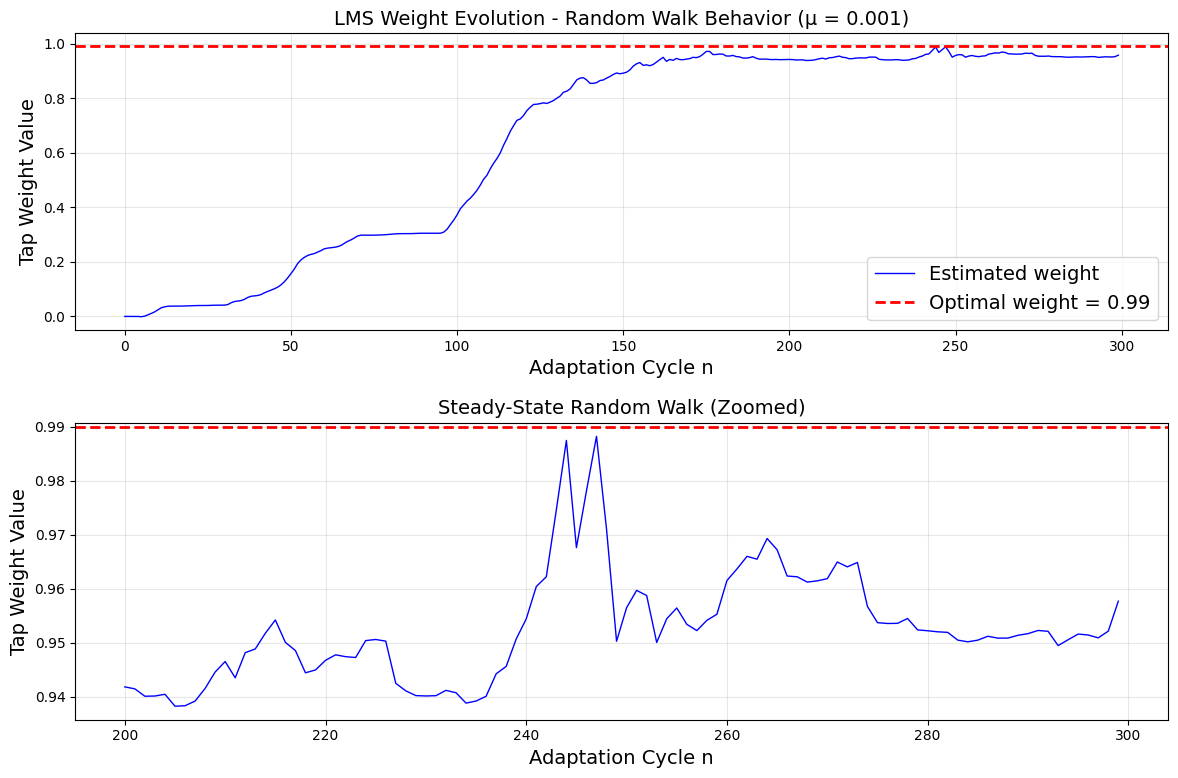

Random Walk Statistics (μ = 0.001):
Optimal weight: 0.9900
Mean steady-state weight: 0.9527
Steady-state std deviation: 0.0100
Bias: -0.0373
Relative variation: 1.01%


In [4]:
# ======================================================
# Simulation settings for random walk analysis
# ======================================================
N_samples = 300                    # More samples to see random walk clearly
N_ensemble = 100                      # Single run to see individual behavior
mu_small = 0.001                    # Small step size for random walk analysis

# Parameters
a = 0.99
noise_u_var = 0.986
noise_u_std = np.sqrt(noise_u_var)

noise_v_var = noise_u_var * (1 - a**2)  # White noise variance
noise_v_std = np.sqrt(noise_v_var)      # White noise standard deviation

rng = np.random.default_rng(42)

# ======================================================
# Single run to observe random walk behavior
# ======================================================
x = np.zeros(N_samples + 1)
w_history = np.zeros(N_samples)     # Store weight evolution
mse_history = np.zeros(N_samples)   # Store MSE evolution

w = 0.0    # Initial weight

# Generate AR(1) process
for n in range(1, N_samples + 1):
    x[n] = a * x[n-1] + rng.normal(0, noise_u_std)

# Run LMS prediction
for n in range(1, N_samples):
    u = x[n-1]       # input from previous step
    d = x[n]         # desired (true process) 
    
    y = w * u
    e = d - y
    
    # LMS update
    w = w + mu_small * u * e
    
    # Store history
    w_history[n] = w
    mse_history[n] = e**2
    
# Theoretical learning curve from Eq (6.109)
n_range = np.arange(N_samples)
theoretical_term1 = noise_u_var * (1 - a**2) * (1 + (mu_small/2) * noise_u_var)
theoretical_term2 = noise_u_var * (a**2 + (mu_small/2) * a**2 * noise_u_var - (mu_small/2) * noise_u_var)
decay_factor = (1 - mu_small * noise_u_var) ** (2 * n_range)

mse_theoretical = theoretical_term1 + theoretical_term2 * decay_factor

# ======================================================
# Plot random walk behavior
# ======================================================
plt.figure(figsize=(12, 8))

# Plot 1: Weight evolution (random walk)
plt.subplot(2, 1, 1)
plt.plot(range(N_samples), w_history, 'b-', linewidth=1, label='Estimated weight')
plt.axhline(y=a, color='r', linestyle='--', linewidth=2, label=f'Optimal weight = {a}')
plt.xlabel('Adaptation Cycle n')
plt.ylabel('Tap Weight Value')
plt.title('LMS Weight Evolution - Random Walk Behavior (μ = 0.001)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Zoom in on steady-state region
plt.subplot(2, 1, 2)
steady_state_start = 200  # Start of steady-state region
plt.plot(range(steady_state_start, N_samples), 
         w_history[steady_state_start:], 'b-', linewidth=1)
plt.axhline(y=a, color='r', linestyle='--', linewidth=2)
plt.xlabel('Adaptation Cycle n')
plt.ylabel('Tap Weight Value')
plt.title('Steady-State Random Walk (Zoomed)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================
# Statistical analysis of random walk
# ======================================================
steady_state_weights = w_history[steady_state_start:]
mean_weight = np.mean(steady_state_weights)
std_weight = np.std(steady_state_weights)

print(f"Random Walk Statistics (μ = {mu_small}):")
print(f"Optimal weight: {a:.4f}")
print(f"Mean steady-state weight: {mean_weight:.4f}")
print(f"Steady-state std deviation: {std_weight:.4f}")
print(f"Bias: {mean_weight - a:.4f}")
print(f"Relative variation: {std_weight/abs(a):.2%}")



#### Computer Experiments 16
In conducting a computer experiment that involves the generation of an $\mathbf{AR}$ process, sometimes not enough time is allowed for the $\mathbf{transients}$ to die out. The purpose of this experiment is to evaluate the effects of such transients on the operation of the $\mathbf{LMS}$ algorithm. Consider, then, the $\mathbf{AR}$ process $u(n)$ of order one described in Section 6.7. The parameters of this process are as follows:

* AR parameter:  $a = -0.99$; 
* AR process variance: $\sigma_{u}^2 = 0.936$; 
* Noise variance:  $\sigma_{v}^2 = 0.02$.

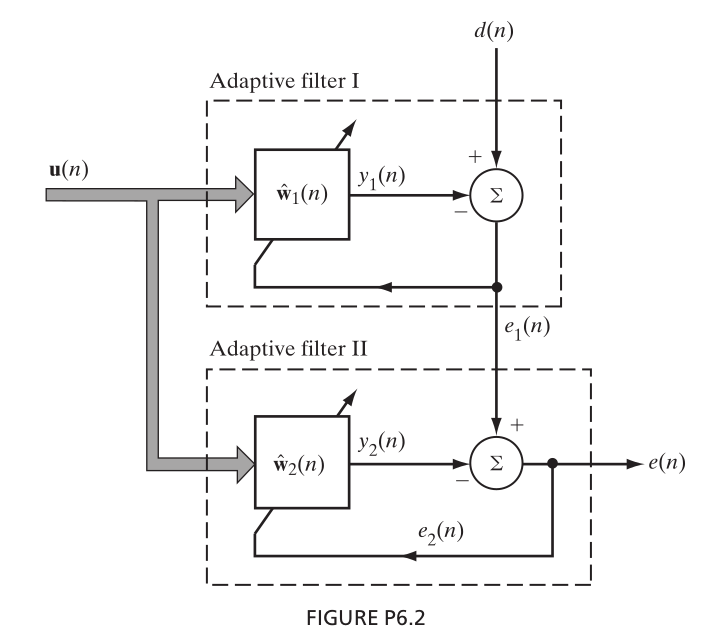

Generate the process $u(n)$ so described for $1 \le n \le 100$, assuming zero initial conditions. Use $u(n)$ as the input of a $\mathbf{linear~adaptive~predictor}$ that is based on the $\mathbf{LMS~algorithm}$ together with a step-size parameter $\mu = 0.05$. In particular, plot the $\mathbf{learning~curve}$ of the predictor by ensemble averaging over 100 independent realizations of the squared value of its output versus adaptation cycle $n$ for $1 \le n \le 100$. Unlike the normal operation of the LMS algorithm, the learning curve so computed should $\mathbf{start~at~the~origin}$, $\mathbf{rise~to~a~peak}$, and then $\mathbf{decay~toward~a~steady-state~value}$. Explain the reason for this phenomenon.

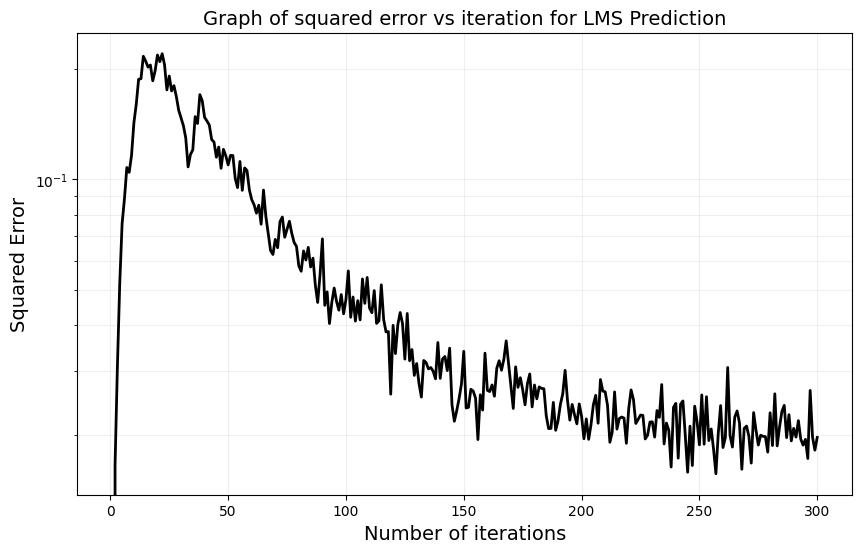

Final MSE: 0.019736
Initial MSE: 0.160309
Convergence ratio: 8.12


In [5]:
import numpy as np
import matplotlib.pyplot as plt

N_samples = 300    # try 300
N_ensemble = 100         
a = -0.99              
noise_u_var = 0.02     
mu = 0.05               
noise_u_std = np.sqrt(noise_u_var)

# Set random seed for reproducibility
np.random.seed(6)

# ======================================================
# Storage arrays
# ======================================================
u = np.zeros(N_samples)      # input data stream
e = np.zeros(N_samples)      # error between prediction and results  
mse = np.zeros(N_samples)    # accumulated squared error

# ======================================================
# Monte Carlo simulations
# ======================================================
for k in range(N_ensemble):
    # Initialize for each run
    u[0] = 0
    w = 0
    
    # Generate data and run LMS
    for n in range(1, N_samples):
        # AR process: u(n) = -a*u(n-1) + noise
        u[n] = -a * u[n-1] + np.random.randn() * noise_u_std
        
        # Prediction error
        e[n] = u[n] - w * u[n-1]
        
        # LMS weight update
        w = w + mu * u[n-1] * e[n]
    
    # Accumulate squared error
    mse = mse + e**2

# Normalize by number of runs
mse = mse / N_ensemble

# ======================================================
# Plot results (semilog scale like MATLAB)
# ======================================================
plt.figure(figsize=(10, 6))
plt.semilogy(range(1, N_samples+1), mse, 'k', linewidth=2)
plt.title('Graph of squared error vs iteration for LMS Prediction')
plt.xlabel('Number of iterations')
plt.ylabel('Squared Error')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Print some statistics
print(f"Final MSE: {mse[-1]:.6f}")
print(f"Initial MSE: {mse[10]:.6f}")  # Skip very first points
print(f"Convergence ratio: {mse[10]/mse[-1]:.2f}")

#### Problem 17

Consider an $\mathbf{AR~process}~u(n)$ defined by the $\mathbf{difference~equation}$
$$
u(n) = -a_1 u(n - 1) - a_2 u(n - 2) + \nu(n),
$$
where $\nu(n)$ is an additive $\mathbf{white~noise}$ of zero mean and $\mathbf{variance}~\sigma_{\nu}^2$. The $\mathbf{AR~parameters}~a_1$ and $a_2$ are both real valued:
$$
a_1 = 0.1; \quad a_2 = -0.8.
$$

Calculate the noise variance $\sigma_{\nu}^2$ such that the AR process $u(n)$ has unit variance. Hence, generate different realizations of the process $u(n)$.

Given the input $u(n)$, an LMS algorithm of length $M=2$ is used to estimate the unknown AR parameters $a_1$ and $a_2$. The step-size parameter $\mu$ is assigned the value $0.05$. 
Justify the use of this design value in the application of the small step-size theory developed in Section 6.4.

(c) For one realization of the LMS algorithm, compute the prediction error
$$
f(n) = u(n) - \hat{u}(n)
$$
and the two tap-weight errors
$$
\epsilon_1(n) = -a_1 - \hat{w}_1(n)
$$
and
$$
\epsilon_2(n) = -a_2 - \hat{w}_2(n).
$$
Using power spectral plots of $f(n)$, $\epsilon_1(n)$, and $\epsilon_2(n)$, show that $f(n)$ behaves as white noise, whereas $\epsilon_1(n)$ and $\epsilon_2(n)$ behave as low-pass~processes.

(d) Compute the ensemble-average learning curve of the LMS algorithm by averaging the squared value of the predictionerror $f(n)$ over an ensemble of 100 different realizations of the filter.

(e) Using the small step-size statistical~theory of Section 6.4, compute the theoretical learning curve of the LMS algorithm and compare your result against the measured result of part (d).


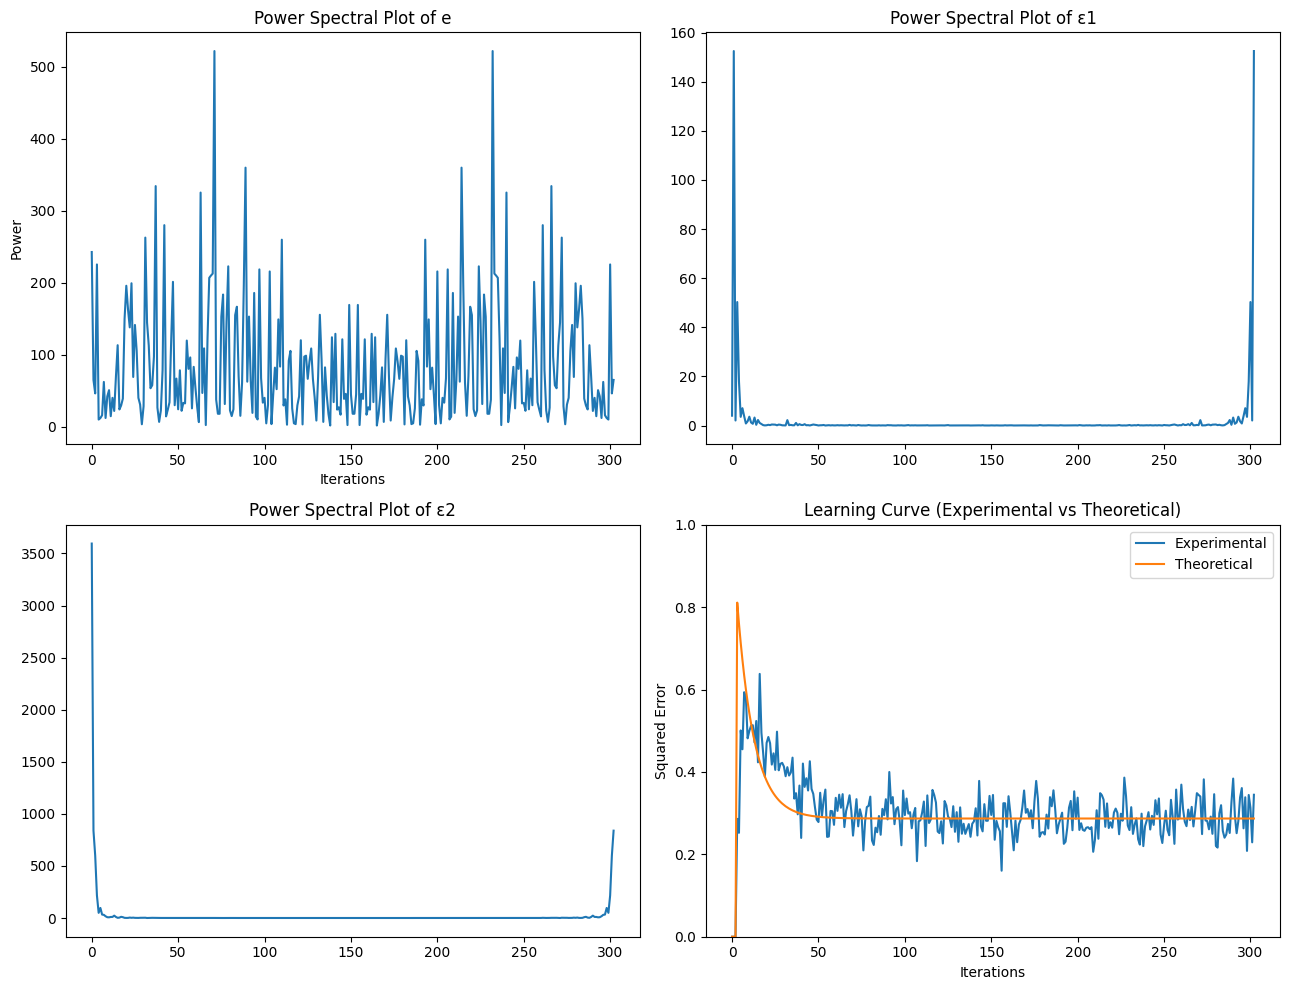

In [2]:
import numpy as np

# -------------------------------------------------------------
# Problem parameters (your preferred naming)
# -------------------------------------------------------------
N_sample     = 300        # number of time samples
N_ensemble   = 100        # number of Monte Carlo runs
a1           = 0.1        # AR parameter
a2           = -0.8       # AR parameter
mu           = 0.05       # LMS step size
var_v        = 0.28       # noise variance (from part a)
std_v        = np.sqrt(var_v)

rng = np.random.default_rng(30)   # reproduce exact behavior

N_init = 3
# -------------------------------------------------------------
# Allocate accumulators
# -------------------------------------------------------------
# +3 to match MATLAB indexing starting at n=3
Ns = N_sample + N_init  

mse_accum = np.zeros(Ns)          # accumulate e(n)^2 over all runs
J_theory = np.zeros(Ns)         # theoretical curve

# -------------------------------------------------------------
# Monte Carlo simulations
# -------------------------------------------------------------
for mc in range(N_ensemble):

    # AR(2) signal
    u = np.zeros(Ns)

    # LMS weights
    W = np.zeros((2, Ns))   # 2-tap predictor

    # Prediction error e
    e = np.zeros(Ns)

    for n in range(N_init, Ns):

        # AR(2) sample
        u[n] = (a1 * u[n-1] + a2 * u[n-2] + rng.normal(0, std_v))

        # Prediction error
        e[n] = u[n] - (W[0,n-1] * u[n-1] + W[1,n-1] * u[n-2])

        # LMS update
        W[:,n] = W[:,n-1] + mu * e[n] * np.array([u[n-1], u[n-2]])

    # Accumulate squared error
    mse_accum += e**2


# -------------------------------------------------------------
# Ensemble average learning curve
# -------------------------------------------------------------
mse_avg = mse_accum / N_ensemble


# -------------------------------------------------------------
# Theoretical curve
# -------------------------------------------------------------
for n in range(N_init, Ns):
    J_theory[n] = (
        (1 - var_v * (1 + mu/2)) * (1 - mu)**(2*n)
        + var_v * (1 + mu/2)
    )


# -------------------------------------------------------------
# Everything below here is optional plotting
# -------------------------------------------------------------
import matplotlib.pyplot as plt
from numpy.fft import fft

index = np.arange(Ns)

plt.figure(figsize=(13,10))

plt.subplot(2,2,1)
plt.plot(index, np.abs(fft(e))**2)
plt.title("Power Spectral Plot of e")
plt.xlabel("Iterations")
plt.ylabel("Power")

plt.subplot(2,2,2)
eps1 = a1 - W[0,:]
plt.plot(index, np.abs(fft(eps1))**2)
plt.title("Power Spectral Plot of ε1")

plt.subplot(2,2,3)
eps2 = a2 - W[1,:]
plt.plot(index, np.abs(fft(eps2))**2)
plt.title("Power Spectral Plot of ε2")

plt.subplot(2,2,4)
plt.plot(index, mse_avg, label="Experimental")
plt.plot(index, J_theory, label="Theoretical")
plt.legend()
plt.title("Learning Curve (Experimental vs Theoretical)")
plt.xlabel("Iterations")
plt.ylabel("Squared Error")
plt.ylim(0,1)

plt.tight_layout()
plt.show()




#### Problem 19
In Section 6.4, we presented the small step-size statistical theory of LMS algorithms. The
purpose of this section is to study what happens to the application of this theory when the
assumption of a small step size is violated.
			
Repeat the experiment on the learning curve of the first-order adaptive predictor plotted
in Fig. 6.18, but this time use the following values for the step-size parameter: 0.001, 0.003,
0.01, 0.03, 0.1, 0.3, 1, 3.
			
Comment on the results so obtained.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parameters
# =====================================================
N_sample    = 300
N_ensemble  = 100
a           = -0.99
var_v       = 0.02
std_v       = np.sqrt(var_v)

mus = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
rng = np.random.default_rng(6)

# =====================================================
# Main experiment
# =====================================================
plt.figure(figsize=(12, 8))

for i, mu in enumerate(mus, start=1):
    mse_accum = np.zeros(N_sample)

    for run in range(N_ensemble):
        u = np.zeros(N_sample)
        e = np.zeros(N_sample)
        w = 0.0

        for n in range(1, N_sample):
            u[n] = -a * u[n-1] + rng.normal(0.0, std_v)
            e[n] = u[n] - w * u[n-1]
            w = w + mu * u[n-1] * e[n]

        # Prevent overflow but keep divergence shape
        mse_accum += np.clip(e**2, 0, 1e6)

    mse = mse_accum / N_ensemble

    plt.subplot(3, 3, i)
    plt.semilogy(range(N_sample), mse, 'k')
    plt.title(f"μ = {mu:g}")
    plt.xlabel("Iteration")
    plt.ylabel("Squared Error")
    plt.grid(True)

plt.tight_layout()
plt.show()



/tmp/ipykernel_101/2142951393.py:35: RuntimeWarning: overflow encountered in square
  mse_accum += np.clip(e**2, 0, 1e6)


NameError: name 'deltas' is not defined

<Figure size 1200x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>